# EQRM on Wild-Time

This notebook runs Empirical Quantile Risk Minimization on the Wild-Time  benchmarks.

**Setup:** Place the `WildTime/` folder in your Google Drive, e.g. at `My Drive/qrm/WildTime/`.

**Runtime:** Use `Runtime → Change runtime type → T4,A100 GPU`.

# Yearbook experiments

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Set path to your WildTime folder

Edit this if your folder is in a different location.

In [2]:
# === EDIT THIS PATH ===
WILDTIME_DIR = "/content/drive/MyDrive/IFT6168/qrm/WildTime"
# ======================

import os
assert os.path.exists(WILDTIME_DIR), f"Path not found: {WILDTIME_DIR}"
assert os.path.exists(os.path.join(WILDTIME_DIR, "train.py")), "train.py not found in WildTime folder"
print(f"WildTime folder found at: {WILDTIME_DIR}")
os.chdir(WILDTIME_DIR)
print(f"Working directory: {os.getcwd()}")
!ls -la

WildTime folder found at: /content/drive/MyDrive/IFT6168/qrm/WildTime
Working directory: /content/drive/MyDrive/IFT6168/qrm/WildTime
total 45
-rw------- 1 root root 13657 Apr 12 22:04 algorithms.py
-rw------- 1 root root  8226 Apr 12 22:04 datasets.py
-rw------- 1 root root     0 Apr 12 22:04 __init__.py
drwx------ 2 root root  4096 Apr 12 22:26 lib
-rw------- 1 root root  1424 Apr 12 22:05 networks.py
-rw------- 1 root root  4179 Apr 12 22:06 README.md
-rw------- 1 root root    48 Apr 12 22:18 requirements.txt
-rw------- 1 root root 12126 Apr 12 22:18 train.py


## 3. Install dependencies

In [3]:
!pip install -q gdown tqdm

## 4. Check GPU

In [5]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 5. Download Yearbook dataset

This downloads `yearbook.pkl` (~50MB) into the `data/` folder. Only needs to run once — the file persists in your Google Drive.

In [6]:
os.makedirs("data", exist_ok=True)
if not os.path.exists("data/yearbook.pkl"):
    !gdown "1mPpxoX2y2oijOvW1ymiHEYd7oMu2vVRb" -O data/yearbook.pkl
    print("Downloaded yearbook.pkl")
else:
    print("yearbook.pkl already exists, skipping download")

import pickle
ds = pickle.load(open("data/yearbook.pkl", "rb"))
years = sorted(ds.keys())
print(f"Years: {years[0]}-{years[-1]} ({len(years)} total)")
print(f"Total train samples: {sum(len(ds[y][0]['labels']) for y in years)}")

Downloading...
From (original): https://drive.google.com/uc?id=1mPpxoX2y2oijOvW1ymiHEYd7oMu2vVRb
From (redirected): https://drive.google.com/uc?id=1mPpxoX2y2oijOvW1ymiHEYd7oMu2vVRb&confirm=t&uuid=7fecd904-8cdd-41eb-9d51-f0a57423fc6e
To: /content/drive/MyDrive/IFT6168/qrm/WildTime/data/yearbook.pkl
100% 1.83G/1.83G [00:23<00:00, 78.5MB/s]
Downloaded yearbook.pkl
Years: 1930-2013 (84 total)
Total train samples: 33431


---
## 6. Run a single experiment

Quick sanity check: run EQRM for a few steps.

In [9]:
!python train.py \
    --dataset yearbook \
    --algorithm eqrm \
    --num_train_envs 8 \
    --alpha -500 \
    --erm_pretrain_iters 200 \
    --steps 500 \
    --eval_freq 100 \
    --seed 0

Args:
	algorithm: eqrm
	alpha: -500.0
	batch_size: 64
	data_dir: data/
	dataset: yearbook
	deterministic: False
	erm_pretrain_iters: 200
	eval_freq: 100
	exp_name: wildtime_eqrm
	groupdro_eta: 1.0
	lr: 0.001
	lr_cos_sched: False
	lr_factor_reduction: 10
	n_workers: 0
	num_train_envs: 8
	output_dir: ./
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	split_time: None
	steps: 500
	weight_decay: 0

Loading yearbook with 8 training environments...
  Train envs: ['1930-1935', '1936-1940', '1941-1945', '1946-1950', '1951-1955', '1956-1960', '1961-1965', '1966-1970'] (8 envs)
  Test envs:  ['1971', '1972', '1973', '1974', '1975']... (43 envs)
  Train env 1930-1935: 1493 samples
  Train env 1936-1940: 1280 samples
  Train env 1941-1945: 2436 samples
  Train env 1946-1950: 1577 samples
  Train env 1951-1955: 1929 samples
  Train env 1956-1960: 1416 samples
  Train env 1961-1965: 1798 samples
  Train env 1966-1970: 2972 samples

Algorithm: EQRM
Total parameters: 28,962
  [Eval step   100] loss

In [8]:
!python train.py \
    --dataset yearbook \
    --algorithm erm \
    --num_train_envs 8 \
    --erm_pretrain_iters 200 \
    --steps 500 \
    --eval_freq 100 \
    --seed 0

Args:
	algorithm: erm
	alpha: -500
	batch_size: 64
	data_dir: data/
	dataset: yearbook
	deterministic: False
	erm_pretrain_iters: 200
	eval_freq: 100
	exp_name: wildtime_eqrm
	groupdro_eta: 1.0
	lr: 0.001
	lr_cos_sched: False
	lr_factor_reduction: 10
	n_workers: 0
	num_train_envs: 8
	output_dir: ./
	penalty_weight: 1000
	save_ckpts: False
	seed: 0
	split_time: None
	steps: 500
	weight_decay: 0

Loading yearbook with 8 training environments...
  Train envs: ['1930-1935', '1936-1940', '1941-1945', '1946-1950', '1951-1955', '1956-1960', '1961-1965', '1966-1970'] (8 envs)
  Test envs:  ['1971', '1972', '1973', '1974', '1975']... (43 envs)
  Train env 1930-1935: 1493 samples
  Train env 1936-1940: 1280 samples
  Train env 1941-1945: 2436 samples
  Train env 1946-1950: 1577 samples
  Train env 1951-1955: 1929 samples
  Train env 1956-1960: 1416 samples
  Train env 1961-1965: 1798 samples
  Train env 1966-1970: 2972 samples

Algorithm: ERM
Total parameters: 28,962
  [Eval step   100] loss=0.2

## 6.5 Sweep EQRM

In [11]:
import subprocess, itertools

alphas = [0.5, 0.75, 0.9, 0.99, -10, -100, -500]
seeds = [0, 1, 2]
steps = 2000
erm_pretrain = 500
num_envs = 8

total = len(alphas) * len(seeds)
print(f"Running {total} experiments (alpha sweep)...\n")

for i, (alpha, seed) in enumerate(itertools.product(alphas, seeds)):
    alpha_str = f"1-e^{int(alpha)}" if alpha < 0 else str(alpha)
    print(f"\n{'='*60}")
    print(f"[{i+1}/{total}] EQRM alpha={alpha_str}, Seed: {seed}")
    print(f"{'='*60}")

    cmd = [
        "python", "train.py",
        "--dataset", "yearbook",
        "--algorithm", "eqrm",
        "--num_train_envs", str(num_envs),
        "--alpha", str(alpha),
        "--steps", str(steps),
        "--erm_pretrain_iters", str(erm_pretrain),
        "--seed", str(seed),
        "--save_ckpts",
        "--exp_name", "alpha_sweep",
    ]

    result = subprocess.run(cmd, capture_output=False)
    if result.returncode != 0:
        print(f"WARNING: alpha={alpha_str} seed {seed} failed!")

print(f"\n\nAll {total} experiments complete!")

Running 21 experiments (alpha sweep)...


[1/21] EQRM alpha=0.5, Seed: 0

[2/21] EQRM alpha=0.5, Seed: 1

[3/21] EQRM alpha=0.5, Seed: 2

[4/21] EQRM alpha=0.75, Seed: 0

[5/21] EQRM alpha=0.75, Seed: 1

[6/21] EQRM alpha=0.75, Seed: 2

[7/21] EQRM alpha=0.9, Seed: 0

[8/21] EQRM alpha=0.9, Seed: 1

[9/21] EQRM alpha=0.9, Seed: 2

[10/21] EQRM alpha=0.99, Seed: 0

[11/21] EQRM alpha=0.99, Seed: 1

[12/21] EQRM alpha=0.99, Seed: 2

[13/21] EQRM alpha=1-e^-10, Seed: 0

[14/21] EQRM alpha=1-e^-10, Seed: 1

[15/21] EQRM alpha=1-e^-10, Seed: 2

[16/21] EQRM alpha=1-e^-100, Seed: 0

[17/21] EQRM alpha=1-e^-100, Seed: 1

[18/21] EQRM alpha=1-e^-100, Seed: 2

[19/21] EQRM alpha=1-e^-500, Seed: 0

[20/21] EQRM alpha=1-e^-500, Seed: 1

[21/21] EQRM alpha=1-e^-500, Seed: 2


All 21 experiments complete!


Loaded 21 results

         α         Avg OOD       Worst OOD             Q10             Q25             Q50             Q75             Q90
       0.5 0.8203 ± 0.0034 0.5366 ± 0.0688 0.6545 ± 0.0130 0.7104 ± 0.0128 0.8571 ± 0.0000 0.9163 ± 0.0096 0.9510 ± 0.0015
      0.75 0.8197 ± 0.0063 0.6008 ± 0.0320 0.6473 ± 0.0093 0.7009 ± 0.0212 0.8507 ± 0.0058 0.9143 ± 0.0017 0.9477 ± 0.0072
       0.9 0.8235 ± 0.0031 0.5968 ± 0.0298 0.6554 ± 0.0022 0.7153 ± 0.0114 0.8468 ± 0.0075 0.9160 ± 0.0042 0.9526 ± 0.0004
      0.99 0.8196 ± 0.0091 0.5516 ± 0.0775 0.6450 ± 0.0142 0.7095 ± 0.0126 0.8473 ± 0.0070 0.9156 ± 0.0036 0.9536 ± 0.0035
 1-e^{-10} 0.8240 ± 0.0045 0.5972 ± 0.0300 0.6554 ± 0.0128 0.7182 ± 0.0129 0.8538 ± 0.0077 0.9173 ± 0.0061 0.9508 ± 0.0011
1-e^{-100} 0.8263 ± 0.0034 0.6240 ± 0.0014 0.6636 ± 0.0170 0.7182 ± 0.0129 0.8538 ± 0.0077 0.9145 ± 0.0065 0.9502 ± 0.0076
1-e^{-500} 0.8233 ± 0.0022 0.6019 ± 0.0327 0.6537 ± 0.0106 0.7158 ± 0.0115 0.8488 ± 0.0060 0.9164 ± 0.0047 0.9479 ± 0.00

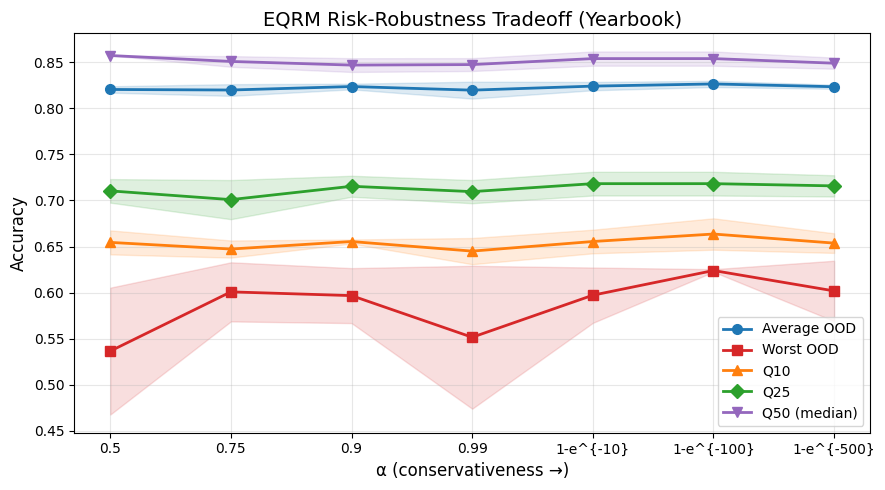

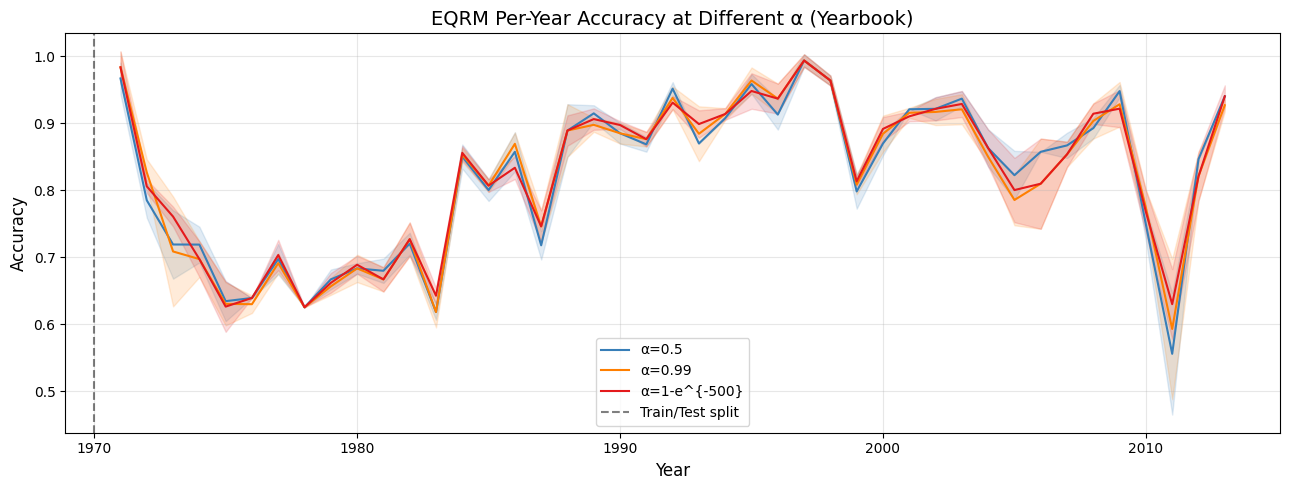

In [12]:
import json, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict

# ── Load results ──
records = []
for f in glob.glob("results/alpha_sweep/*.jsonl"):
    with open(f) as fp:
        for line in fp:
            records.append(json.loads(line.strip()))

print(f"Loaded {len(records)} results\n")

# Group by alpha
alpha_results = defaultdict(list)
for r in records:
    alpha = r["args"]["alpha"]
    alpha_results[alpha].append(r)

alphas_sorted = sorted(alpha_results.keys(), key=lambda a: a if a >= 0 else 1 - np.exp(a))
alpha_labels = [f"1-e^{{{int(a)}}}" if a < 0 else str(a) for a in alphas_sorted]

# ── Table ──
rows = []
for alpha, label in zip(alphas_sorted, alpha_labels):
    runs = alpha_results[alpha]
    def fmt(key):
        vals = [r[key] for r in runs if key in r]
        if not vals: return "-"
        return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"
    rows.append({
        "α": label,
        "Avg OOD": fmt("avg_ood_acc_best"),
        "Worst OOD": fmt("worst_ood_acc_best"),
        "Q10": fmt("q0.1_acc_best"),
        "Q25": fmt("q0.25_acc_best"),
        "Q50": fmt("q0.5_acc_best"),
        "Q75": fmt("q0.75_acc_best"),
        "Q90": fmt("q0.9_acc_best"),
    })
print(pd.DataFrame(rows).to_string(index=False))

# ── Plot 1: Risk-Robustness Tradeoff ──
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(alphas_sorted))

for key, label, marker, color in [
    ("avg_ood_acc_best",   "Average OOD",  "o-", "#1f77b4"),
    ("worst_ood_acc_best", "Worst OOD",    "s-", "#d62728"),
    ("q0.1_acc_best",      "Q10",          "^-", "#ff7f0e"),
    ("q0.25_acc_best",     "Q25",          "D-", "#2ca02c"),
    ("q0.5_acc_best",      "Q50 (median)", "v-", "#9467bd"),
]:
    means = np.array([np.mean([r[key] for r in alpha_results[a] if key in r]) for a in alphas_sorted])
    stds  = np.array([np.std([r[key] for r in alpha_results[a] if key in r]) for a in alphas_sorted])
    ax.plot(x, means, marker, label=label, color=color, linewidth=2, markersize=7)
    ax.fill_between(x, means - stds, means + stds, alpha=0.15, color=color)

ax.set_xticks(x)
ax.set_xticklabels(alpha_labels, fontsize=10)
ax.set_xlabel("α (conservativeness →)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("EQRM Risk-Robustness Tradeoff (Yearbook)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("alpha_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Per-year accuracy for low / mid / high alpha ──
fig, ax = plt.subplots(figsize=(13, 5))

selected = [alphas_sorted[0], alphas_sorted[len(alphas_sorted)//2], alphas_sorted[-1]]
colors_sel = ["#377eb8", "#ff7f00", "#e41a1c"]

for alpha, color in zip(selected, colors_sel):
    runs = alpha_results[alpha]
    year_accs = defaultdict(list)
    for r in runs:
        for k, v in r.items():
            if k.endswith("_acc_best") and k[0].isdigit():
                year = int(k.split("_")[0])
                year_accs[year].append(v)
    if not year_accs:
        continue
    years_s = sorted(year_accs.keys())
    means = [np.mean(year_accs[y]) for y in years_s]
    stds = [np.std(year_accs[y]) for y in years_s]
    label = f"α=1-e^{{{int(alpha)}}}" if alpha < 0 else f"α={alpha}"
    ax.plot(years_s, means, label=label, color=color, linewidth=1.5)
    ax.fill_between(years_s, np.array(means)-np.array(stds), np.array(means)+np.array(stds),
                    alpha=0.15, color=color)

ax.axvline(x=1970, color="black", linestyle="--", alpha=0.5, label="Train/Test split")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("EQRM Per-Year Accuracy at Different α (Yearbook)", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("alpha_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Full sweep: all algorithms × 3 seeds

This runs EQRM and all baselines. Takes ~30–45 min on a T4 GPU.

In [14]:
import subprocess, itertools

algorithms = ["erm", "eqrm", "vrex", "groupdro", "irm"]
seeds = [0, 1, 2]
steps = 2000
erm_pretrain = 500
num_envs = 8

total = len(algorithms) * len(seeds)
print(f"Running {total} experiments...\n")

for i, (algo, seed) in enumerate(itertools.product(algorithms, seeds)):
    print(f"\n{'='*60}")
    print(f"[{i+1}/{total}] Algorithm: {algo.upper()}, Seed: {seed}")
    print(f"{'='*60}")

    cmd = [
        "python", "train.py",
        "--dataset", "yearbook",
        "--algorithm", algo,
        "--num_train_envs", str(num_envs),
        "--steps", str(steps),
        "--erm_pretrain_iters", str(erm_pretrain),
        "--seed", str(seed),
        "--save_ckpts",
        "--exp_name", "yearbook_sweep",
    ]

    # EQRM-specific
    if algo == "eqrm":
        cmd += ["--alpha", "0.75"]

    # Penalty-based methods
    if algo in ["vrex", "irm"]:
        cmd += ["--penalty_weight", "1000"]

    result = subprocess.run(cmd, capture_output=False)
    if result.returncode != 0:
        print(f"WARNING: {algo} seed {seed} failed!")

print(f"\n\nAll {total} experiments complete!")

Running 15 experiments...


[1/15] Algorithm: ERM, Seed: 0

[2/15] Algorithm: ERM, Seed: 1

[3/15] Algorithm: ERM, Seed: 2

[4/15] Algorithm: EQRM, Seed: 0

[5/15] Algorithm: EQRM, Seed: 1

[6/15] Algorithm: EQRM, Seed: 2

[7/15] Algorithm: VREX, Seed: 0

[8/15] Algorithm: VREX, Seed: 1

[9/15] Algorithm: VREX, Seed: 2

[10/15] Algorithm: GROUPDRO, Seed: 0

[11/15] Algorithm: GROUPDRO, Seed: 1

[12/15] Algorithm: GROUPDRO, Seed: 2

[13/15] Algorithm: IRM, Seed: 0

[14/15] Algorithm: IRM, Seed: 1

[15/15] Algorithm: IRM, Seed: 2


All 15 experiments complete!


---
## 8. Collect and compare results

In [15]:
import json
import glob
import pandas as pd
import numpy as np

# Load all result files
result_files = glob.glob("results/yearbook_sweep/*.jsonl")
print(f"Found {len(result_files)} result files\n")

records = []
for f in result_files:
    with open(f) as fp:
        for line in fp:
            records.append(json.loads(line.strip()))

# Build summary table
rows = []
for r in records:
    rows.append({
        "Algorithm": r.get("algorithm", "").upper(),
        "Seed": r.get("seed", ""),
        "Avg OOD": r.get("avg_ood_acc_best", 0),
        "Worst OOD": r.get("worst_ood_acc_best", 0),
        "Q10": r.get("q0.1_acc_best", 0),
        "Q25": r.get("q0.25_acc_best", 0),
        "Q50 (median)": r.get("q0.5_acc_best", 0),
        "Q75": r.get("q0.75_acc_best", 0),
        "Q90": r.get("q0.9_acc_best", 0),
    })

df = pd.DataFrame(rows)
print("=" * 80)
print("PER-RUN RESULTS")
print("=" * 80)
print(df.to_string(index=False))

# Aggregate: mean ± std across seeds
print("\n" + "=" * 80)
print("AGGREGATED (mean ± std across seeds)")
print("=" * 80)
metrics = ["Avg OOD", "Worst OOD", "Q10", "Q25", "Q50 (median)", "Q75", "Q90"]
agg = df.groupby("Algorithm")[metrics].agg(["mean", "std"])

# Format as mean ± std
summary_rows = []
for algo in agg.index:
    row = {"Algorithm": algo}
    for m in metrics:
        mean = agg.loc[algo, (m, "mean")]
        std = agg.loc[algo, (m, "std")]
        row[m] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Found 15 result files

PER-RUN RESULTS
Algorithm  Seed  Avg OOD  Worst OOD      Q10      Q25  Q50 (median)      Q75      Q90
      ERM     0 0.835079   0.555556 0.694444 0.760000      0.857143 0.921569 0.940000
      ERM     1 0.844381   0.625000 0.703125 0.769231      0.854167 0.928571 0.958333
      ERM     2 0.855125   0.638889 0.750000 0.769231      0.888889 0.928571 0.960784
     EQRM     0 0.824511   0.555556 0.634146 0.740000      0.850000 0.923077 0.952381
     EQRM     1 0.826335   0.597561 0.653846 0.700000      0.857143 0.913043 0.953125
     EQRM     2 0.825712   0.555556 0.662338 0.700000      0.857143 0.925926 0.958333
     VREX     0 0.845305   0.666667 0.695122 0.779221      0.846154 0.934783 0.953125
     VREX     1 0.846706   0.583333 0.707317 0.780488      0.857143 0.935897 0.968750
     VREX     2 0.852627   0.638889 0.708333 0.780000      0.860000 0.935484 0.960784
 GROUPDRO     0 0.826502   0.638889 0.666667 0.733333      0.843137 0.921569 0.968750
 GROUPDRO     1

---
## 9. Plot: Quantile performance comparison

This is the key figure from the EQRM paper's evaluation protocol (Tables 2–3, Fig. 4).

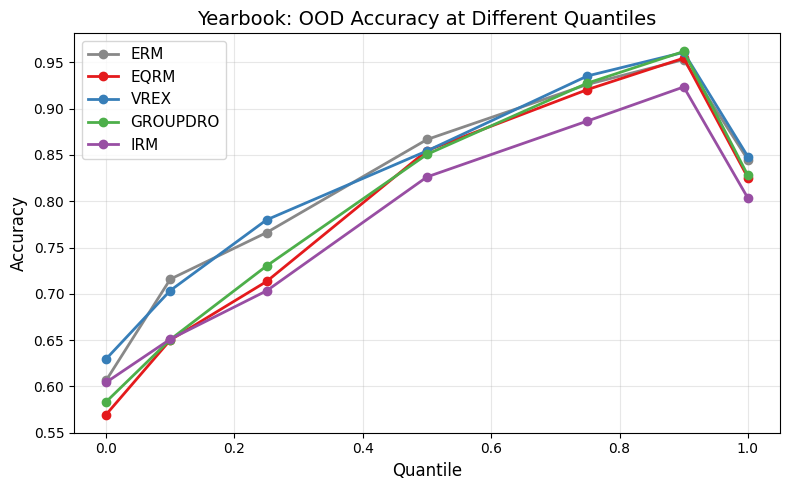

Saved to quantile_comparison.png


In [16]:
import matplotlib.pyplot as plt

quantile_levels = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
quantile_keys_best = ["worst_ood_acc_best", "q0.1_acc_best", "q0.25_acc_best",
                      "q0.5_acc_best", "q0.75_acc_best", "q0.9_acc_best", "avg_ood_acc_best"]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
colors = {"ERM": "#888888", "EQRM": "#e41a1c", "VREX": "#377eb8",
          "GROUPDRO": "#4daf4a", "IRM": "#984ea3"}

for algo in df["Algorithm"].unique():
    algo_df = df[df["Algorithm"] == algo]
    vals = []
    for qk in quantile_keys_best:
        col = qk.replace("_best", "").replace("_acc", "").replace("worst_ood", "Worst OOD").replace("avg_ood", "Avg OOD")
        # Find matching column
        for r in records:
            if r.get("algorithm", "").upper() == algo:
                vals.append(r.get(qk, 0))
                break

    # Simpler approach: use aggregated data
    algo_records = [r for r in records if r.get("algorithm", "").upper() == algo]
    if not algo_records:
        continue

    mean_vals = []
    for qk in quantile_keys_best:
        v = np.mean([r.get(qk, 0) for r in algo_records])
        mean_vals.append(v)

    ax.plot(quantile_levels, mean_vals, "o-", label=algo,
            color=colors.get(algo, "black"), linewidth=2, markersize=6)

ax.set_xlabel("Quantile", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Yearbook: OOD Accuracy at Different Quantiles", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("quantile_comparison.png", dpi=150)
plt.show()
print("Saved to quantile_comparison.png")

---
## 10. Plot: Per-year accuracy over time

Shows how each algorithm's accuracy evolves across test years (temporal OOD).

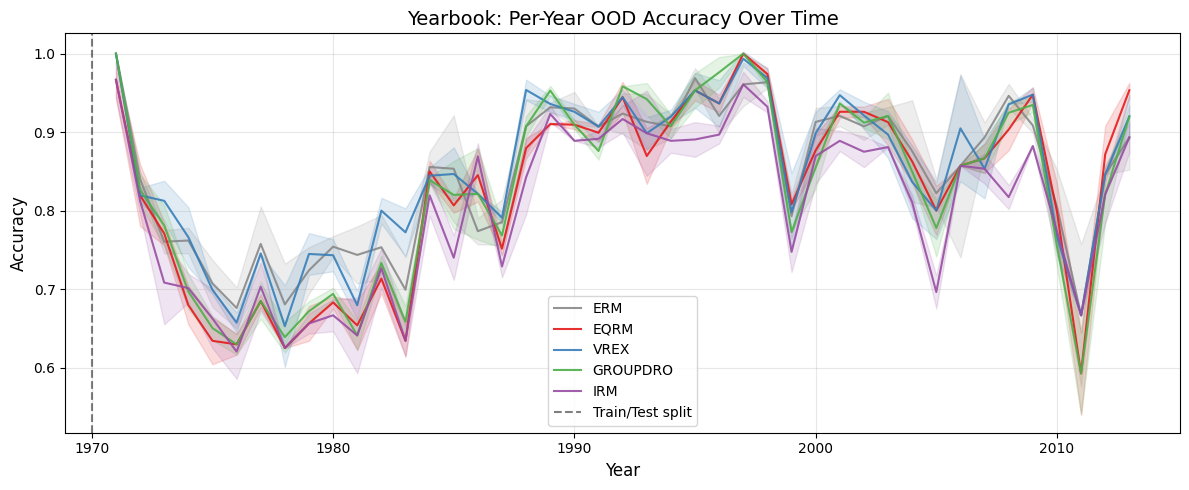

Saved to per_year_accuracy.png


In [17]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

for algo in ["ERM", "EQRM", "VREX", "GROUPDRO", "IRM"]:
    algo_records = [r for r in records if r.get("algorithm", "").upper() == algo]
    if not algo_records:
        continue

    # Collect per-year test accuracies
    year_accs = {}
    for r in algo_records:
        for k, v in r.items():
            if k.endswith("_acc_best") and k[0].isdigit():
                year = int(k.split("_")[0])
                if year not in year_accs:
                    year_accs[year] = []
                year_accs[year].append(v)

    if not year_accs:
        continue

    years_sorted = sorted(year_accs.keys())
    means = [np.mean(year_accs[y]) for y in years_sorted]
    stds = [np.std(year_accs[y]) for y in years_sorted]

    ax.plot(years_sorted, means, label=algo,
            color=colors.get(algo, "black"), linewidth=1.5, alpha=0.9)
    ax.fill_between(years_sorted,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.15, color=colors.get(algo, "black"))

ax.axvline(x=1970, color="black", linestyle="--", alpha=0.5, label="Train/Test split")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Yearbook: Per-Year OOD Accuracy Over Time", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("per_year_accuracy.png", dpi=150)
plt.show()
print("Saved to per_year_accuracy.png")

# FMoW experiments

In [2]:
# ── Cell 1: Setup ──
from google.colab import drive
drive.mount('/content/drive')

# === EDIT THIS PATH ===
WILDTIME_DIR = "/content/drive/MyDrive/IFT6168/qrm/WildTime"
# ======================

import os
assert os.path.exists(os.path.join(WILDTIME_DIR, "train.py")), f"train.py not found in {WILDTIME_DIR}"
os.chdir(WILDTIME_DIR)

!pip install -q wilds gdown tqdm
import torch
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch 2.10.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ── Cell 2: Run FMoW — ERM vs EQRM × temporal vs geographic ──
import subprocess, itertools

configs = [
    {"dataset": "fmow_temporal", "algorithm": "erm",  "num_train_envs": "6"},
    {"dataset": "fmow_temporal", "algorithm": "eqrm", "num_train_envs": "6", "alpha": "0.75"},
    {"dataset": "fmow_geo",     "algorithm": "erm"},
    {"dataset": "fmow_geo",     "algorithm": "eqrm",  "alpha": "0.75"},
]
seeds = [0, 1, 2]

total = len(configs) * len(seeds)
print(f"Running {total} experiments...\n")

for i, (cfg, seed) in enumerate(itertools.product(configs, seeds)):
    ds = cfg["dataset"]
    algo = cfg["algorithm"]
    extra = {k: v for k, v in cfg.items() if k not in ("dataset", "algorithm")}
    extra_str = " ".join(f"{k}={v}" for k, v in extra.items())
    print(f"\n{'='*60}")
    print(f"[{i+1}/{total}] {ds} | {algo.upper()} {extra_str} | seed={seed}")
    print(f"{'='*60}")

    cmd = [
        "python", "train.py",
        "--dataset", ds,
        "--algorithm", algo,
        "--steps", "3000",
        "--erm_pretrain_iters", "500",
        "--batch_size", "32",
        "--lr", "1e-4",
        "--seed", str(seed),
        "--save_ckpts",
        "--exp_name", "fmow_comparison",
    ]
    for k, v in extra.items():
        cmd += [f"--{k}", str(v)]

    result = subprocess.run(cmd, capture_output=False)
    if result.returncode != 0:
        print(f"  FAILED!")

print(f"\n\nAll {total} experiments complete!")

In [ ]:
# ── Cell 3: Results table + plots ──
import json, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict

records = []
for f in glob.glob("results/fmow_comparison/*.jsonl"):
    with open(f) as fp:
        for line in fp:
            records.append(json.loads(line.strip()))

print(f"Loaded {len(records)} results\n")

temporal = defaultdict(list)
geo = defaultdict(list)
for r in records:
    algo = r.get("algorithm", "").upper()
    ds = r.get("dataset", "")
    if ds == "fmow_temporal":
        temporal[algo].append(r)
    elif ds == "fmow_geo":
        geo[algo].append(r)

# ── Table ──
quantile_keys = [
    ("worst_ood_acc_best", "Worst"),
    ("q0.1_acc_best", "Q10"),
    ("q0.25_acc_best", "Q25"),
    ("q0.5_acc_best", "Q50"),
    ("q0.75_acc_best", "Q75"),
    ("q0.9_acc_best", "Q90"),
    ("avg_ood_acc_best", "Avg"),
]

def fmt(runs, key):
    vals = [r[key] for r in runs if key in r]
    if not vals: return "-"
    return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"

rows = []
for split_name, grouped in [("Temporal", temporal), ("Geographic", geo)]:
    for algo in ["ERM", "EQRM"]:
        if algo not in grouped: continue
        row = {"Split": split_name, "Algorithm": algo}
        for key, label in quantile_keys:
            row[label] = fmt(grouped[algo], key)
        rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

# ── Plot 1: Side-by-side quantile curves ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, grouped, title in [
    (axes[0], temporal, "Temporal Envs (years)"),
    (axes[1], geo, "Geographic Envs (regions)"),
]:
    for algo, color, lw in [("ERM", "#888888", 1.5), ("EQRM", "#e41a1c", 2.5)]:
        if algo not in grouped: continue
        runs = grouped[algo]
        q_levels = [q for _, q in [
            ("worst_ood_acc_best", 0.0), ("q0.1_acc_best", 0.1),
            ("q0.25_acc_best", 0.25), ("q0.5_acc_best", 0.5),
            ("q0.75_acc_best", 0.75), ("q0.9_acc_best", 0.9),
            ("avg_ood_acc_best", 1.0),
        ]]
        keys = ["worst_ood_acc_best", "q0.1_acc_best", "q0.25_acc_best",
                "q0.5_acc_best", "q0.75_acc_best", "q0.9_acc_best", "avg_ood_acc_best"]
        means = np.array([np.mean([r[k] for r in runs if k in r]) for k in keys])
        stds = np.array([np.std([r[k] for r in runs if k in r]) for k in keys])

        ax.plot(q_levels, means, "o-", label=algo, color=color, linewidth=lw, markersize=7)
        ax.fill_between(q_levels, means - stds, means + stds, alpha=0.15, color=color)

    ax.set_xlabel("Quantile", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)

axes[0].set_ylabel("Accuracy", fontsize=12)
fig.suptitle("FMoW: ERM vs EQRM — Temporal vs Geographic Environments", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fmow_temporal_vs_geo.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: EQRM improvement over ERM ──
fig, ax = plt.subplots(figsize=(9, 5))

keys = ["worst_ood_acc_best", "q0.1_acc_best", "q0.25_acc_best",
        "q0.5_acc_best", "q0.75_acc_best", "q0.9_acc_best", "avg_ood_acc_best"]
q_levels = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

for split_name, grouped, color, marker in [
    ("Temporal (years)", temporal, "#ff7f0e", "s"),
    ("Geographic (regions)", geo, "#1f77b4", "o"),
]:
    if "ERM" not in grouped or "EQRM" not in grouped: continue
    erm_means = [np.mean([r[k] for r in grouped["ERM"] if k in r]) for k in keys]
    eqrm_means = [np.mean([r[k] for r in grouped["EQRM"] if k in r]) for k in keys]
    deltas = [e - b for e, b in zip(eqrm_means, erm_means)]

    ax.plot(q_levels, deltas, f"{marker}-", label=split_name,
            color=color, linewidth=2.5, markersize=8)

ax.axhline(y=0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Quantile", fontsize=12)
ax.set_ylabel("EQRM accuracy − ERM accuracy", fontsize=12)
ax.set_title("Does Environment Definition Matter for EQRM?", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("fmow_eqrm_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fmow_temporal_vs_geo.png, fmow_eqrm_delta.png")